Como Método a seguir / modelo de referencia uno puede generalizarlo a los siguientes pasos:

# *Modelar ➔ Dimensionar ➔ Operar ➔ Transformar ➔ Decidir*



En donde

el 1ro *MODELAR*, acá tenemos que traducir la realidad a Vectores y Matrices de NumPy.

el 2do *DIMENSIONAR*, .shape (la mitad de los errores acá son de forma, no de cuentas).

el 3ro *OPERAR*, es donde hacemos los cálculos masivos decidiendo inteligentemente si usar el producto matricial (`@`), la multiplicación elemento a elemento (`*`) o colapsar datos con (`axis`).

el 4to *TRANSFORMAR*, acá aplicamos matrices especiales (como la matriz diagonal, identidad o la transpuesta `.T`)

el 5to *DECIDIR*, es donde juntamos los resultados matemáticos y los volvemos a pasar a un formato presentable (DataFrame de Pandas) para comunicar el resultado y tomar una decisión de negocios.



---


# Vamos a ver un caso de Ventas Semanalas de un local con varias sucursales



Este es simple y artificial, pero aplicado a las organizaciones, para así ver el método propuesto y después poder lidiar con casos reales y más complejos, que a la vez son más interesantes!



---
### 1) **MODELAR**

In [15]:
import numpy as np

# Listas de referencia para no perdernos
productos = ["Cafés", "Medialunas", "Tostados"]
sucursales = ["Centro", "Recoleta", "Belgrano"]

# Matriz de Ventas Semanales
ventas = np.array([
    [500, 350, 420],  # Cafés
    [300, 200, 250],  # Medialunas
    [150, 100, 180]   # Tostados
])

# Vector de Precios de Venta (en $)
precios = np.array([[1500, 800, 3500]])

# Vector de Costos de Producción (en $)
costos = np.array([[400, 200, 1200]])

print("✅ Negocio modelado correctamente en NumPy.")

✅ Negocio modelado correctamente en NumPy.


*Filas: Productos | Columnas: Sucursales*

---
### 2) **DIMENSIONAR**

vemos las dimensiones de la matriz y de los vectores, y chequeamos que ambos digan filas y columnas, asi python no asume que es y nosotros sabemos que tenemos sin delegar en python

In [16]:
Dimension_ventas = ventas.shape
Dimension_precios = precios.shape
Dimension_costos = costos.shape

print(f"Matriz de Ventas : {Dimension_ventas} -> ({Dimension_ventas[0]} productos x {Dimension_ventas[1]} sucursales)")
print(f"\nVector Precios   : {Dimension_precios} -> 1 fila 3 columnas")
print(f"\nVector Costos   : {Dimension_costos} -> 1 fila 3 columnas")


# Para multiplicar Precios (3 elementos) por Ventas (3 filas), el álgebra exige usar el operador correcto.

Matriz de Ventas : (3, 3) -> (3 productos x 3 sucursales)

Vector Precios   : (1, 3) -> 1 fila 3 columnas

Vector Costos   : (1, 3) -> 1 fila 3 columnas


---
### ⚠️ Disclaimer Práctico: El poder de la Transpuesta (`.T`)

En este ejercicio definimos los precios como un vector fila de `(1, 3)` para que la multiplicación sea directa. Sin embargo, los datos tambien pueden venir en formato vertical (como un **Vector Columna** de `3x1`).

Si intentamos multiplicar un vector columna `(3x1)` directo contra nuestra matriz de ventas `(3x3)`, el álgebra falla porque las dimensiones internas (1 y 3) no coinciden.

Para solucionar esto, usamos simplemente la **Transpuesta (`.T`)**, que  "acuesta" la columna y nos permite operar.

In [42]:
# Simulamos una bajada de base de datos donde los precios vienen en vertical (3 filas x 1 columna)
precios_columna = np.array([
    [1500],
    [800],
    [3500]
])

print(f"Dimensiones del nuevo vector: {precios_columna.shape}\n")

# LA SOLUCIÓN: Usamos .T para transponer (acostar) el vector a (1x3) y que el @ funcione
ingresos_demostracion = precios_columna.T @ ventas

#ya vamos a ver que hace .flatten() mas adelante en esta notebook...
ingresos_demostracion_aplanados = ingresos_demostracion.flatten()

print(f"Operación exitosa usando la transpuesta: \n{ingresos_demostracion_aplanados}")
print(f"\nNuevas dimensiones tras la operación: {ingresos_demostracion.shape}")


Dimensiones del nuevo vector: (3, 1)

Operación exitosa usando la transpuesta: 
[1515000 1035000 1460000]

Nuevas dimensiones tras la operación: (1, 3)




---


### 3) **OPERAR**

*PREGUNTA 1*: Unidades por sucursal

*PREGUNTA 2*: Ingresos Brutos por sucursal

In [17]:
# 1
# Queremos que "desaparezcan" los productos y queden las sucursales. Colapsamos las FILAS (axis=0).
unidades_por_sucursal = ventas.sum(axis=0)

print(f"Unidades por Sucursal: {unidades_por_sucursal}")


# esto es solo para que vea lindo, lo importante es entender que da ventas.sum(axis=0 u 1)
print("\n📦 Unidades totales vendidas por sucursal:")
for suc, cant in zip(sucursales, unidades_por_sucursal):
    print(f"- {suc}: {cant} unidades")

# 2
# Usamos el PRODUCTO MATRICIAL (@). Multiplica cada precio por la cantidad de su producto y suma el total.

ingresos_brutos = precios @ ventas

# Aplanamos el resultado: pasamos de una matriz con "listas adentro de listas"
# (ej: [[100, 200]]) a una lista simple y plana (ej: [100, 200]) para poder leerla fácil
ingresos_brutos = ingresos_brutos.flatten()

print(f"\nIngresos Brutos: {ingresos_brutos}")

# esto es solo para que vea lindo, lo importante es entender que da matriz1 @ matriz2)
print("\n💰 Ingresos Brutos por sucursal:")
for suc, ingreso in zip(sucursales, ingresos_brutos):
    print(f"- {suc}: ${ingreso:,.2f}")


Unidades por Sucursal: [950 650 850]

📦 Unidades totales vendidas por sucursal:
- Centro: 950 unidades
- Recoleta: 650 unidades
- Belgrano: 850 unidades

Ingresos Brutos: [1515000 1035000 1460000]

💰 Ingresos Brutos por sucursal:
- Centro: $1,515,000.00
- Recoleta: $1,035,000.00
- Belgrano: $1,460,000.00


` OJO:`
 Si usáramos "precios * ventas", nos daría una matriz del mismo tamaño, no un total por sucursal.
Que se veria asi:

In [18]:
error_multiplicacion = precios * ventas
print(f"Resultado: \n{error_multiplicacion}")
print("\n-> nos devuelve otra matriz, no el resultado de un producto matricial; por la naturaleza de la operacion matematica")

Resultado: 
[[ 750000  280000 1470000]
 [ 450000  160000  875000]
 [ 225000   80000  630000]]

-> nos devuelve otra matriz, no el resultado de un producto matricial; por la naturaleza de la operacion matematica




---


### **4) TRANSFORMAR**

Buscamos el **Beneficio Neto**, que se calcula como ingresos brutos - costos reales

Para obtener los **Costos Reales**, primero debemos calcular los **Costos Teóricos** (que serian, costos por ventas).

Finalmente, como el flete y la logística castigan distinto a cada local, **TRANSFORMAMOS** esos costos teóricos multiplicándolos por una **Matriz Diagonal**.

Como vimos en la teorica esta matriz especial nos permite aplicar la penalidad operativa exacta a cada sucursal del país en una sola línea de código, evitando usar bucles y obteniendo los costos reales definitivos.

In [28]:
# Primero calculamos el Costo Teórico de cada sucursal (Costos @ Ventas)
costos_teoricos = costos @ ventas

# Creamos la Matriz Diagonal de Eficiencia
matriz_eficiencia = np.diag([1.10, 1.00, 0.95])
print("Matriz Diagonal de Eficiencia Logística:\n", matriz_eficiencia)

# TRANSFORMACIÓN: Ajustamos los costos teóricos a la realidad de cada sucursal
costos_reales = costos_teoricos @ matriz_eficiencia

# Calculamos el Beneficio Real (Ingresos - Costos Reales)
beneficio_real = ingresos_brutos - costos_reales

#aplanamos de nuevo..
costos_teoricos_aplanados = costos_teoricos.flatten()
costos_reales_aplanados = costos_reales.flatten()
beneficio_real_aplanados = beneficio_real.flatten()

print(f"\nCostos Teoricos: {costos_teoricos_aplanados}")
print(f"\nCostos Reales: {costos_reales_aplanados}")
print(f"\nBeneficio Real: {beneficio_real_aplanados}")

Matriz Diagonal de Eficiencia Logística:
 [[1.1  0.   0.  ]
 [0.   1.   0.  ]
 [0.   0.   0.95]]

Costos Teoricos: [440000 300000 434000]

Costos Reales: [484000. 300000. 412300.]

Beneficio Real: [1031000.  735000. 1047700.]




---


### **5) DECIDIR**

Vamos a mostrar estos datos de matrices, como informacion de un dataframe

Creamos el dataframe mediante diccionarios y los arrays

Agregamos una nueva columna con informacion que nos interesa mediante los datos

Ordenamos en orden ascendente por beneficio neto

Mostramos el dataframe


In [35]:
import pandas as pd

# Armamos el DataFrame Final
reporte = pd.DataFrame({
    "Sucursal": sucursales,
    "Ingresos ($)": ingresos_brutos,
    "Costos Reales ($)": costos_reales_aplanados,
    "Beneficio Neto ($)": beneficio_real_aplanados
})

# Agregamos una métrica clave de gestión: Margen de Ganancia (%)
reporte["Margen (%)"] = (reporte["Beneficio Neto ($)"] / reporte["Ingresos ($)"] * 100).round(2)

# Ordenamos por la sucursal que más plata nos deja en el bolsillo
reporte_final = reporte.sort_values(by="Beneficio Neto ($)", ascending=False).reset_index(drop=True)

print("REPORTE DE FINAL:")
display(reporte_final)

REPORTE DE FINAL:


,Sucursal,Ingresos ($),Costos Reales ($),Beneficio Neto ($),Margen (%)
0,Belgrano,1460000,412300.0,1047700.0,71.76
1,Centro,1515000,484000.0,1031000.0,68.05
2,Recoleta,1035000,300000.0,735000.0,71.01


**`Extra`**


Visualizamos la rentabilidad

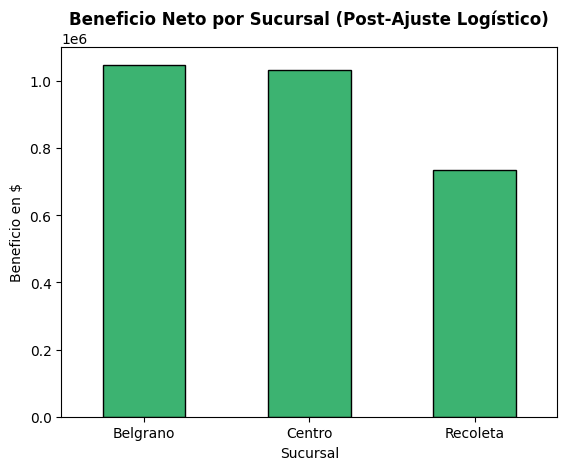

In [33]:
# Importamos la librería estrella de visualización (suele importarse al principio, pero la ponemos acá para el fin de la notebook complementaria)
import matplotlib.pyplot as plt


reporte_final.plot(x="Sucursal", y="Beneficio Neto ($)", kind="bar", color="mediumseagreen", edgecolor="black", legend=False)

plt.title("Beneficio Neto por Sucursal (Post-Ajuste Logístico)", fontweight="bold")
plt.ylabel("Beneficio en $")
plt.xticks(rotation=0)

plt.show()




---

***Como Breve resumen del caso y del metodo propuesto***

# *Modelar ➔ Dimensionar ➔ Operar ➔ Transformar ➔ Decidir*




| Etapa y Error a evitar | Comando / Solución  |
|---|---|
| **Modelar:** Definir vectores como filas o columnas, no sin dimension | vector columna: `np.array([[1], [2], [3]])` o vector fila: `np.array([[1,2,3]])`
| **Dimensionar:** Multiplicar a ciegas provocando un `ValueError` | Chequear `matriz.shape` |
| **Operar:** Colapsar el eje equivocado al totalizar datos | `A.sum(axis=0)` (aplasta filas) vs `A.sum(axis=1)` (aplasta columnas) |
| **Operar:** Usar `*` (celda a celda) en vez de sumar la caja registradora | Usar SIEMPRE el producto matricial `@` para aplicar precios a cantidades |
| **Transformar:** Arrastrar matrices 2D ("listas adentro de listas") que rompen a Pandas | Aplanar `.flatten()` |
| **Transformar:** Chocar dimensiones al multiplicar un vector columna por una matriz | Usar la Transpuesta para "acostar" el vector: `vector.T @ matriz` |
| **Transformar:** Usar un bucle `for` para aplicar tasas o mermas distintas | Multiplicar de una con `np.diag([a, b, c])` |
